In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C://Users//vinic//OneDrive//Área de Trabalho//base_datathon_pm_vf.xlsx")

In [2]:
df.describe()

,ID_ALUNO,ANO,ANO_INGRESSO,BOLSISTA,CF,CG,CT,DEFASAGEM,FASE,IDADE_ALUNO,INDICADO_BOLSA,NOTA_ING,NOTA_MAT,NOTA_PORT,PONTO_VIRADA
count,4759.000000,4759.000000,3345.000000,4758.000000,862.000000,862.000000,862.000000,3716.000000,4031.000000,727.000000,4759.000000,1326.000000,3162.000000,3161.000000,4759.000000
mean,731.322967,2022.248792,2021.467862,0.022699,75.396752,431.500000,6.617169,-0.663079,2.468370,12.408528,0.027737,6.193917,6.256894,6.274496,0.072494
std,421.285218,1.370854,1.840922,0.148957,52.314184,248.982262,3.989485,0.854121,2.154441,2.829807,0.164235,2.788158,2.306512,2.244685,0.259332
min,1.000000,2020.000000,2016.000000,0.000000,1.000000,1.000000,1.000000,-5.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,381.000000,2021.000000,2021.000000,0.000000,30.000000,216.250000,3.000000,-1.000000,1.000000,10.000000,0.000000,4.300000,5.000000,5.000000,0.000000
50%,729.000000,2022.000000,2022.000000,0.000000,66.500000,431.500000,6.000000,-1.000000,2.000000,12.000000,0.000000,6.500000,6.500000,6.500000,0.000000
75%,1070.000000,2023.000000,2023.000000,0.000000,118.000000,646.750000,9.750000,0.000000,4.000000,14.000000,0.000000,8.500000,8.000000,8.000000,0.000000
max,1661.000000,2024.000000,2024.000000,1.000000,192.000000,862.000000,18.000000,3.000000,9.000000,20.000000,1.000000,10.000000,10.000000,10.000000,1.000000


In [3]:
df.head(1)

,NOME,ID_ALUNO,ANO,ANO_INGRESSO,BOLSISTA,CF,CG,CT,DEFASAGEM,FASE,...,INDE,INDICADO_BOLSA,IPP,IPS,IPV,NOTA_ING,NOTA_MAT,NOTA_PORT,PEDRA,PONTO_VIRADA
0,ALUNO-1,1,2020,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,7.883752,0,5.9375,7.5,7.75,NaN,NaN,NaN,Ametista,0


In [4]:
df['PEDRA'] = df['PEDRA'].astype(str).str.strip()
df['PEDRA'] = df['PEDRA'].replace({
    'Agata': 'Ágata',
    'Ágata': 'Ágata', 
    'Quartzo ': 'Quartzo',
    'Topazio': 'Topázio',
    'Ametista ': 'Ametista'
})
pedras_validas = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df = df[df['PEDRA'].isin(pedras_validas)]
ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df['PEDRA'] = pd.Categorical(df['PEDRA'], categories=ordem, ordered=True)

Pergunta 1. Adequação do nível (IAN) -> Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? 

(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

In [5]:
df['IAN'] = (df['IAN'].astype(str).str.replace(',', '.'))
df['IAN'] = pd.to_numeric(df['IAN'], errors='coerce')
df['IAN'].describe()

count    4571.000000
mean        7.006673
std         2.513097
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64

In [6]:
# df['IAN'].unique()
df['IAN'].value_counts()

IAN
5.0     2624
10.0    1872
2.5       75
Name: count, dtype: int64

In [7]:
def classificar_ian(x):
    if x == 10:
        return 'Em Fase'
    elif x == 5:
        return 'Moderada'
    elif x == 2.5:
        return 'Severa'
    else:
        return 'Alta Defasagem'

df['FAIXA_IAN'] = df['IAN'].apply(classificar_ian)

In [8]:
df['FAIXA_IAN'].value_counts()

FAIXA_IAN
Moderada    2624
Em Fase     1872
Severa        75
Name: count, dtype: int64

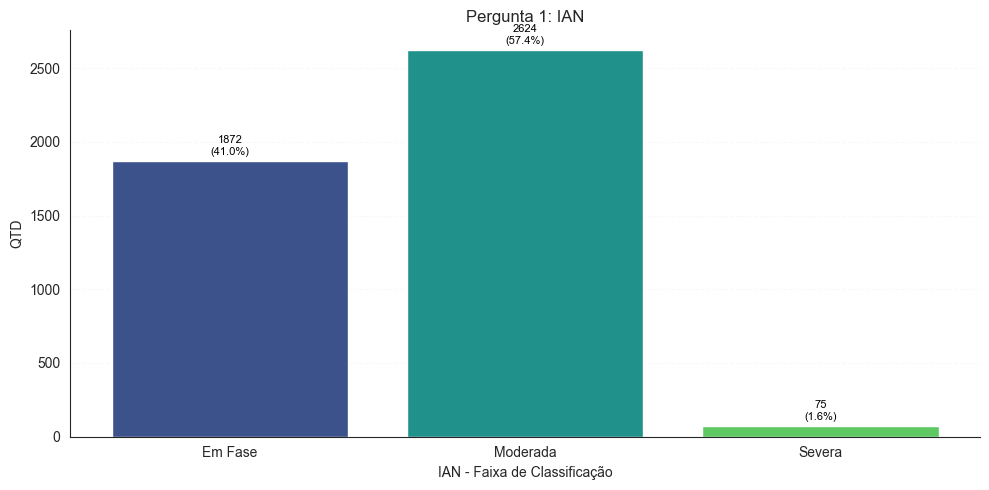

In [9]:
contagem = df['FAIXA_IAN'].value_counts().sort_index()
percentual = contagem / contagem.sum() * 100
plt.figure(figsize=(10,5))
sns.set_style("white")
bars = plt.bar(contagem.index, contagem.values, color=sns.color_palette('viridis', len(contagem)))
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

for i, bar in enumerate(bars):
    altura = bar.get_height()
    pct = percentual.iloc[i]
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + (contagem.max() * 0.01), 
        f'{int(altura)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )
plt.title('Pergunta 1: IAN')
plt.xlabel('IAN - Faixa de Classificação')
plt.ylabel('QTD')
plt.xticks(contagem.index) 

plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

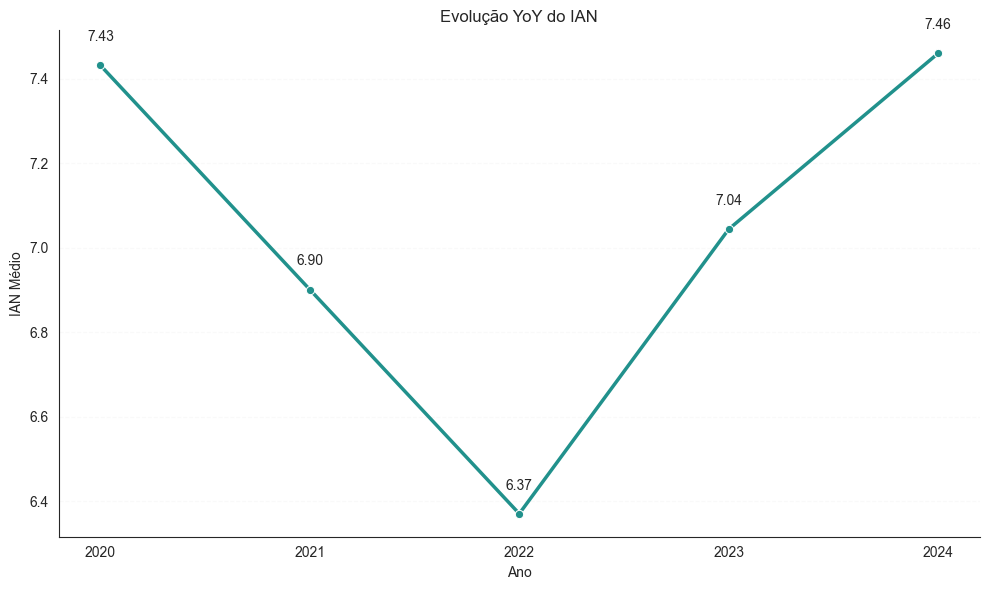

In [10]:
evolucao_yoy = df.groupby('ANO')['IAN'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.set_style("white")
sns.lineplot(data=evolucao_yoy,x='ANO',y='IAN',marker='o',linewidth=2.5,color=sns.color_palette('viridis', 3)[1])
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

for i in range(len(evolucao_yoy)):
    x = evolucao_yoy['ANO'].iloc[i]
    y = evolucao_yoy['IAN'].iloc[i]
    
    plt.text(x,
        y + 0.05, 
        f'{y:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Evolução YoY do IAN')
plt.xlabel('Ano')
plt.ylabel('IAN Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.xticks(evolucao_yoy['ANO'].astype(int))

plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\1147136528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fase_IAN,x='PEDRA',y='IAN',order=ordem,palette=sns.color_palette('viridis', len(fase_IAN)))


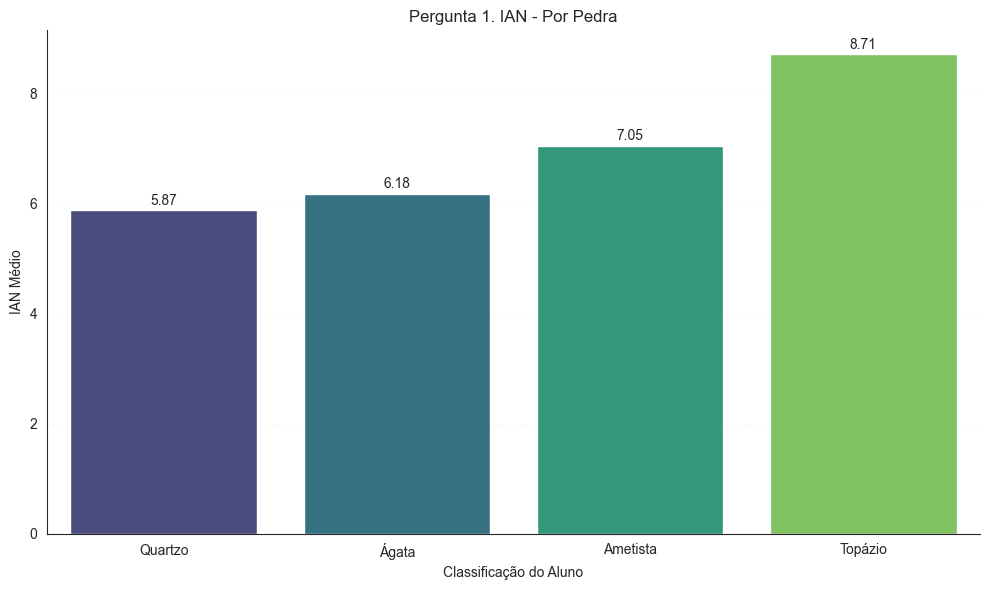

In [11]:
fase_IAN = df.groupby('PEDRA')['IAN'].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=fase_IAN,x='PEDRA',y='IAN',order=ordem,palette=sns.color_palette('viridis', len(fase_IAN)))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + 0.05, 
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title('Pergunta 1. IAN - Por Pedra')
plt.xlabel('Classificação do Aluno')
plt.ylabel('IAN Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------

Pergunta 2. Desempenho acadêmico (IDA) 

 O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [12]:
df['IDA'] = (df['IDA'].astype(str).str.replace(',', '.'))
df['IDA'] = pd.to_numeric(df['IDA'], errors='coerce')
df['IDA'].describe()

count    4571.000000
mean        6.200758
std         2.203631
min         0.000000
25%         4.900000
50%         6.500000
75%         7.800000
max        10.000000
Name: IDA, dtype: float64

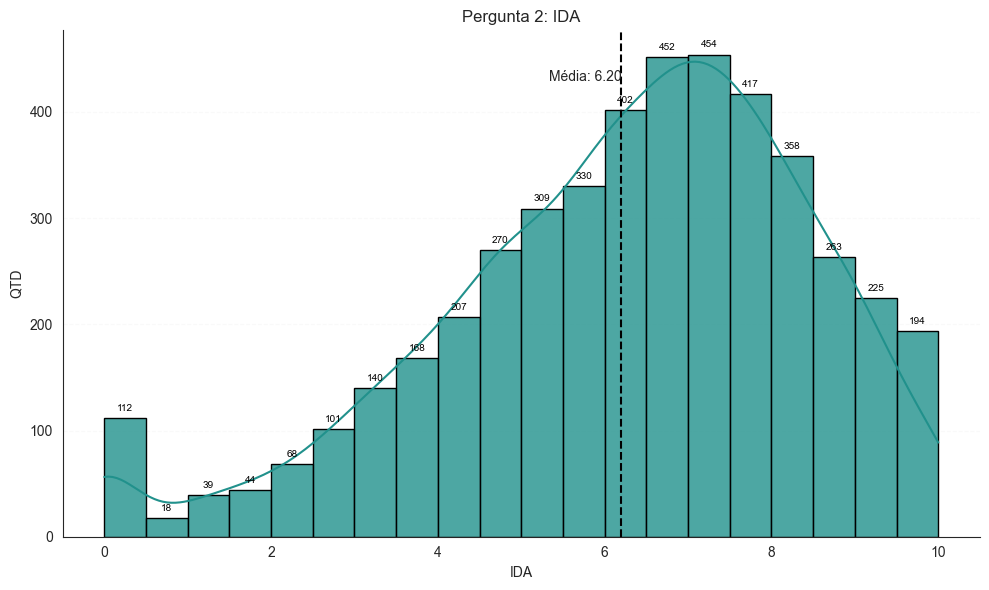

In [13]:
plt.figure(figsize=(10,6))
sns.set_style("white")
ax = sns.histplot(df['IDA'],bins=20,kde=True,color=sns.color_palette('viridis', 3)[1],edgecolor='black',alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


media = df['IDA'].mean()
plt.axvline(media, linestyle='--', linewidth=1.5, color='black')
plt.text(media, ax.get_ylim()[1]*0.9, f'Média: {media:.2f}', ha='right')

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + (ax.get_ylim()[1]*0.01),
            f'{int(altura)}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=7.2
        )

plt.title('Pergunta 2: IDA')
plt.xlabel('IDA')
plt.ylabel('QTD')

plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [14]:
def classificar_ida(x):
    if x >= 8:
        return 'Alto Desempenho'
    elif x >= 6:
        return 'Esperado'
    elif x >= 4:
        return 'Baixo Desempenho'
    else:
        return 'Alerta - Crítico'

df['FAIXA_IDA'] = df['IDA'].apply(classificar_ida)
# df['FAIXA_IDA'].value_counts()
df['FAIXA_IDA'].value_counts(normalize=True)

FAIXA_IDA
Esperado            0.377379
Baixo Desempenho    0.244148
Alto Desempenho     0.227521
Alerta - Crítico    0.150952
Name: proportion, dtype: float64

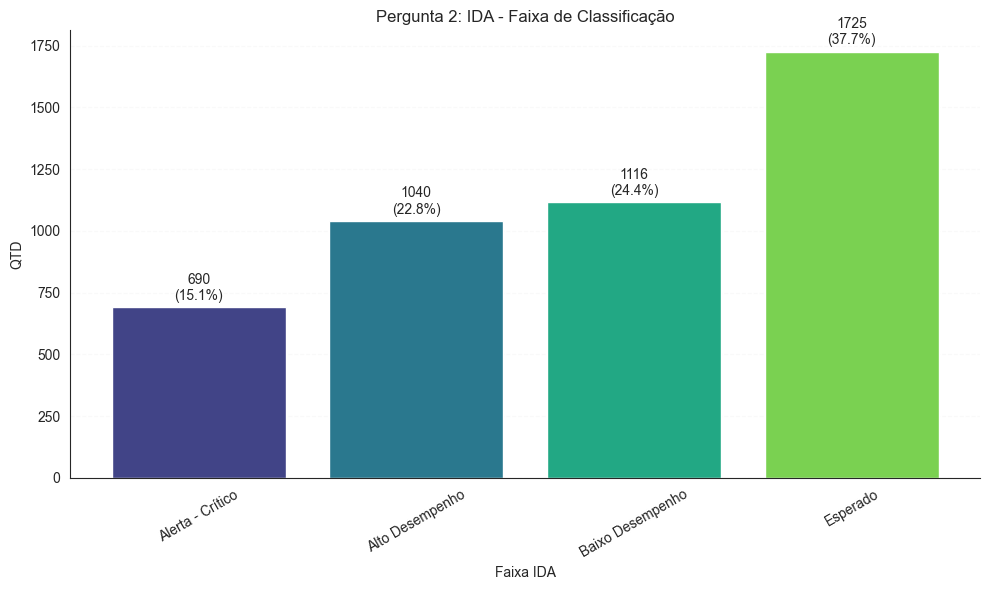

In [15]:
contagem = df['FAIXA_IDA'].value_counts().sort_index()
percentual = contagem / contagem.sum() * 100
sns.set_style("white")
plt.figure(figsize=(10,6))

bars = plt.bar(contagem.index,contagem.values,color=sns.color_palette('viridis', len(contagem)))
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
for i, bar in enumerate(bars):
    altura = bar.get_height()
    pct = percentual.iloc[i]
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + (contagem.max() * 0.01),
        f'{int(altura)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Pergunta 2: IDA - Faixa de Classificação')
plt.xlabel('Faixa IDA')
plt.ylabel('QTD')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

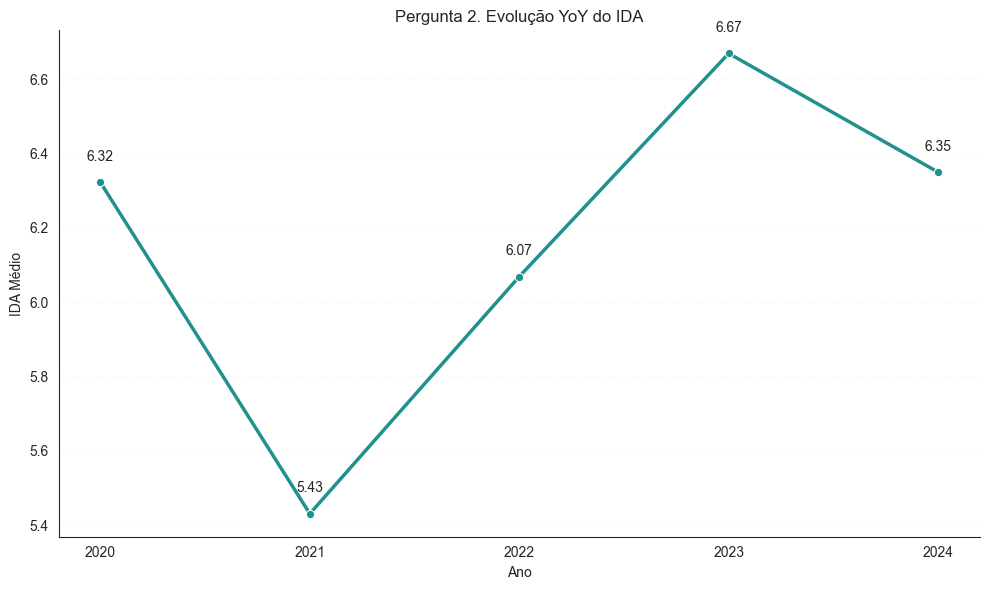

In [16]:
evolucao = df.groupby('ANO')['IDA'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.set_style("white")
sns.lineplot(data=evolucao,x='ANO',y='IDA',marker='o',linewidth=2.5,color=sns.color_palette('viridis', 3)[1])

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

for i in range(len(evolucao)):
    x = evolucao['ANO'].iloc[i]
    y = evolucao['IDA'].iloc[i]
    plt.text(
        x,
        y + 0.05,  
        f'{y:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Pergunta 2. Evolução YoY do IDA')
plt.xlabel('Ano')
plt.ylabel('IDA Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.xticks(evolucao['ANO'].astype(int))

plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\3429018658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fase_ida,x='PEDRA',y='IDA',order=ordem,palette=sns.color_palette('viridis', len(fase_ida)))


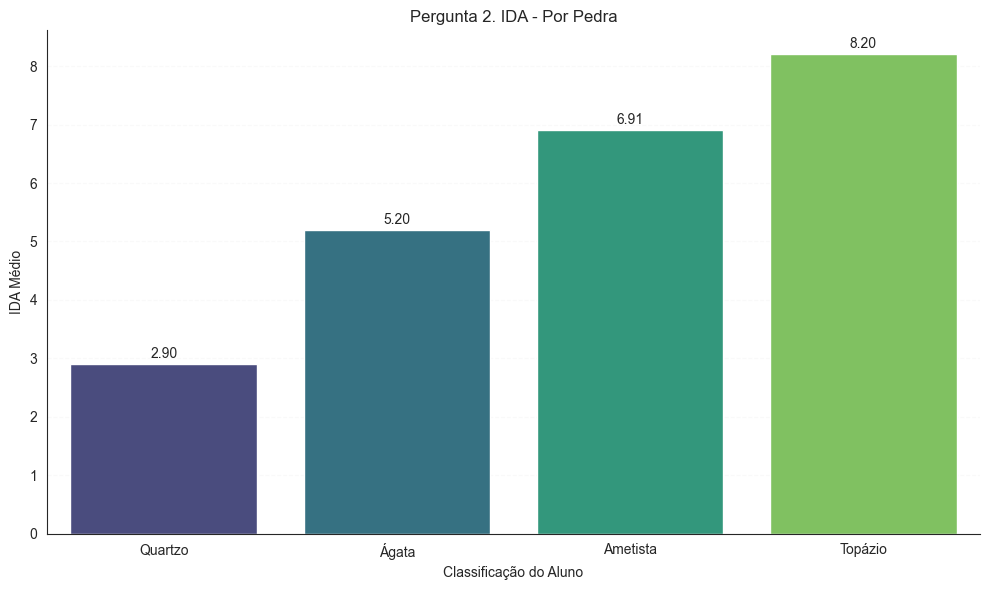

In [17]:
fase_ida = df.groupby('PEDRA')['IDA'].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=fase_ida,x='PEDRA',y='IDA',order=ordem,palette=sns.color_palette('viridis', len(fase_ida)))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + 0.05, 
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title('Pergunta 2. IDA - Por Pedra')
plt.xlabel('Classificação do Aluno')
plt.ylabel('IDA Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------

Pergunta 3. Engajamento nas atividades (IEG) 

O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [18]:
df['IEG'] = (df['IEG'].astype(str).str.replace(',', '.'))
df['IEG'] = pd.to_numeric(df['IEG'], errors='coerce')

df['IEG'].describe()

count    4571.000000
mean        7.904982
std         1.934235
min         0.000000
25%         7.000000
50%         8.406839
75%         9.347826
max        10.000000
Name: IEG, dtype: float64

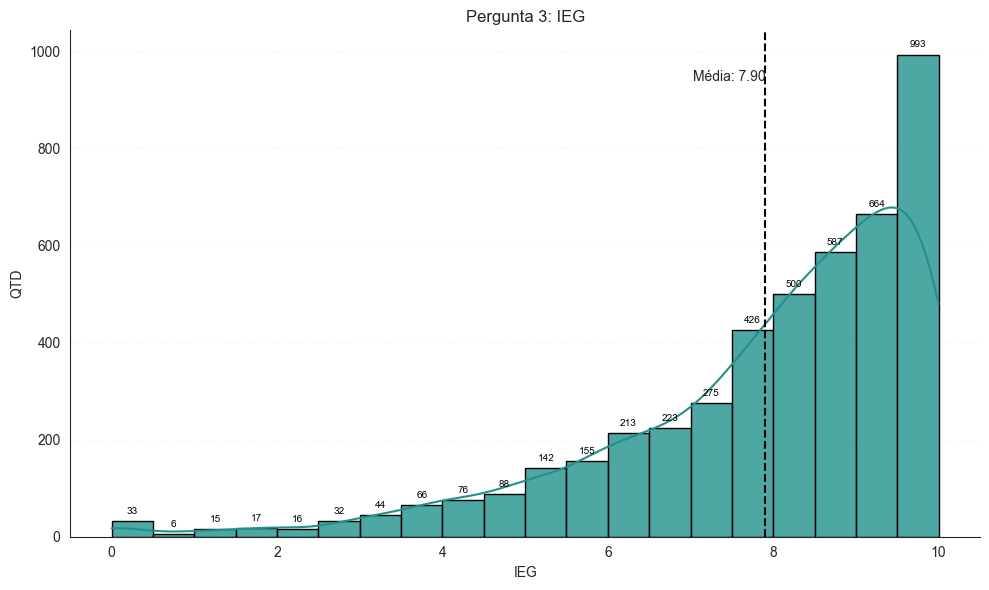

In [19]:
plt.figure(figsize=(10,6))
sns.set_style("white")
ax = sns.histplot(df['IEG'],bins=20,kde=True,color=sns.color_palette('viridis', 3)[1],edgecolor='black',alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

media = df['IEG'].mean()
plt.axvline(media, linestyle='--', linewidth=1.5, color='black')
plt.text(media,ax.get_ylim()[1]*0.9,f'Média: {media:.2f}',ha='right')
for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + (ax.get_ylim()[1]*0.01),
            f'{int(altura)}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=7.2
        )
plt.title('Pergunta 3: IEG')
plt.xlabel('IEG')
plt.ylabel('QTD')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [20]:
def classificar_ieg(x):
    if x >= 9:
        return 'Muito Alto'
    elif x >= 7:
        return 'Alto'
    elif x >= 5:
        return 'Moderado'
    else:
        return 'Baixo'

df['FAIXA_IEG'] = df['IEG'].apply(classificar_ieg)
# df['FAIXA_IEG'].value_counts()
df['FAIXA_IEG'].value_counts(normalize=True)

FAIXA_IEG
Alto          0.391162
Muito Alto    0.362503
Moderado      0.160359
Baixo         0.085977
Name: proportion, dtype: float64

In [21]:
ordem_IEG = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_IEG'] = pd.Categorical(df['FAIXA_IEG'], categories=ordem_IEG, ordered=True)

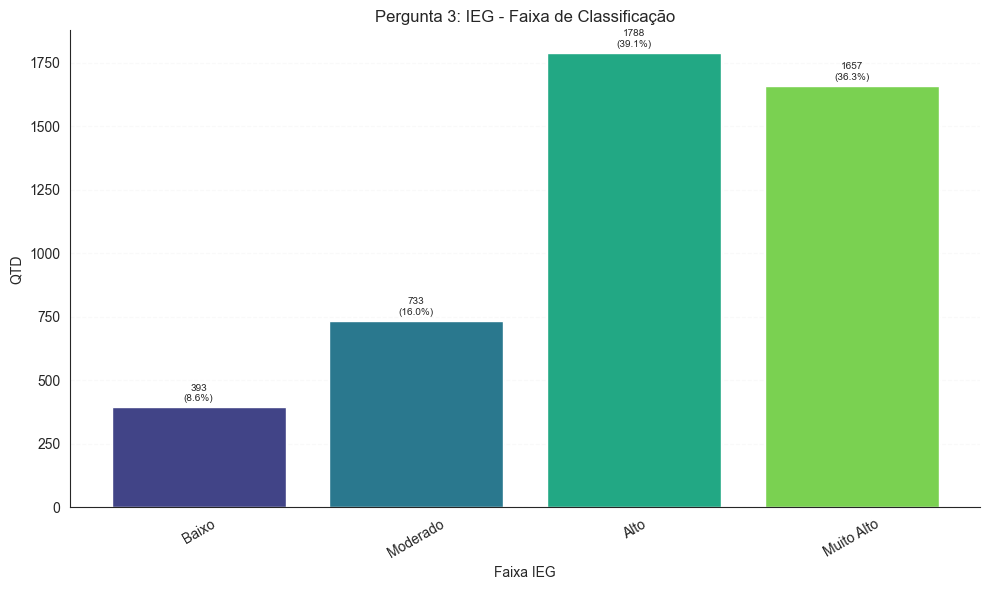

In [22]:
contagem = df['FAIXA_IEG'].value_counts().sort_index()
percentual = contagem / contagem.sum() * 100
sns.set_style("white")
plt.figure(figsize=(10,6))

bars = plt.bar(contagem.index,contagem.values,color=sns.color_palette('viridis', len(contagem)))
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
for i, bar in enumerate(bars):
    altura = bar.get_height()
    pct = percentual.iloc[i]
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + (contagem.max() * 0.01),
        f'{int(altura)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=7.2
    )
plt.title('Pergunta 3: IEG - Faixa de Classificação')
plt.xlabel('Faixa IEG')
plt.ylabel('QTD')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

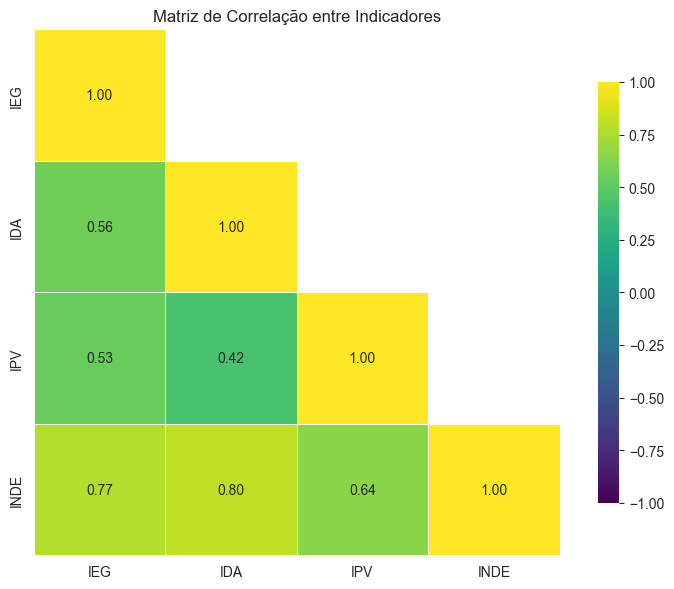

In [23]:
corr = df[['IEG', 'IDA', 'IPV','INDE']].corr()
diagonal = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8,6))
sns.set_style("white")

ax = sns.heatmap(
    corr,
    mask=diagonal,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Matriz de Correlação entre Indicadores')
plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\874529245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fase_IEG,x='PEDRA',y='IEG',palette=sns.color_palette('viridis', len(fase_IEG)))


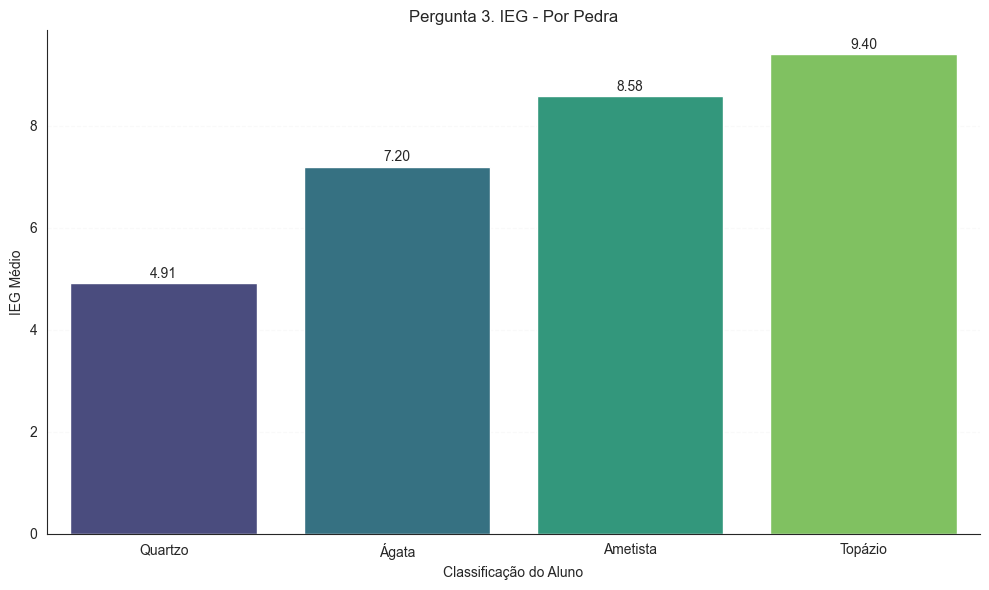

In [24]:
fase_IEG = df.groupby('PEDRA')['IEG'].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=fase_IEG,x='PEDRA',y='IEG',palette=sns.color_palette('viridis', len(fase_IEG)))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + 0.05, 
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title('Pergunta 3. IEG - Por Pedra')
plt.xlabel('Classificação do Aluno')
plt.ylabel('IEG Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------

Pergunta 4. Autoavaliação (IAA)

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [25]:
df['IAA'] = (df['IAA'].astype(str).str.replace(',', '.'))
df['IAA'] = pd.to_numeric(df['IAA'], errors='coerce')
df['IAA'].describe()

count    4570.000000
mean        8.047583
std         2.407490
min         0.000000
25%         7.916670
50%         8.751000
75%         9.500000
max        10.002000
Name: IAA, dtype: float64

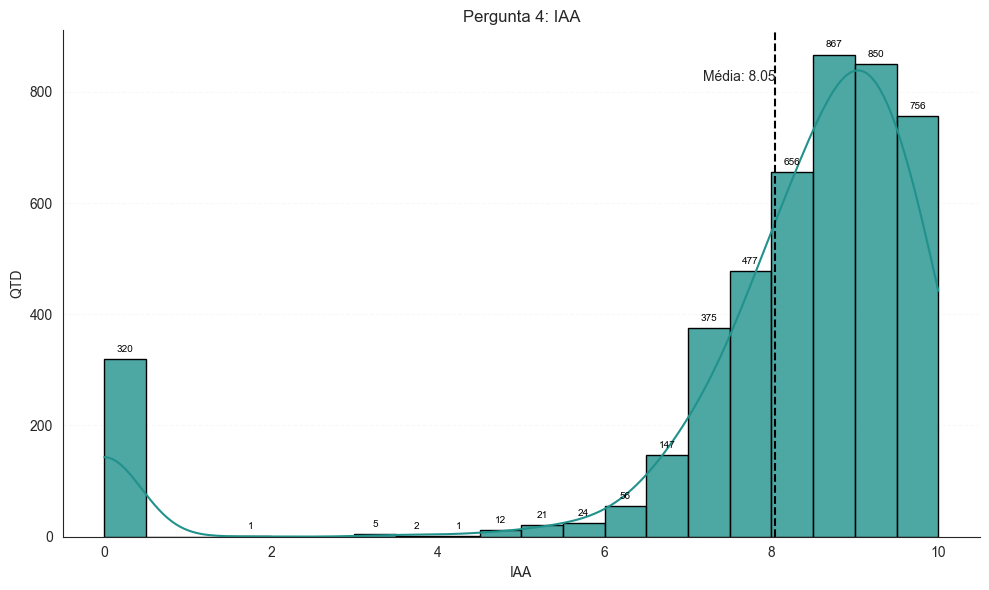

In [26]:
plt.figure(figsize=(10,6))
sns.set_style("white")
ax = sns.histplot(df['IAA'],bins=20,kde=True,color=sns.color_palette('viridis', 3)[1],edgecolor='black',alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

media = df['IAA'].mean()
plt.axvline(media, linestyle='--', linewidth=1.5, color='black')
plt.text(media,ax.get_ylim()[1]*0.9,f'Média: {media:.2f}',ha='right')
for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + (ax.get_ylim()[1]*0.01),
            f'{int(altura)}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=7.2
        )
plt.title('Pergunta 4: IAA')
plt.xlabel('IAA')
plt.ylabel('QTD')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [27]:
def classificar_iaa(x):
    if x >= 9:
        return 'Muito Alto'
    elif x >= 8:
        return 'Alto'
    elif x >= 6:
        return 'Moderado'
    else:
        return 'Baixo'

df['FAIXA_IAA'] = df['IAA'].apply(classificar_iaa)
df['FAIXA_IAA'].value_counts(normalize=True)


FAIXA_IAA
Muito Alto    0.457887
Alto          0.265806
Moderado      0.191643
Baixo         0.084664
Name: proportion, dtype: float64

In [28]:
ordem_IAA = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_IAA'] = pd.Categorical(df['FAIXA_IAA'], categories=ordem_IAA, ordered=True)

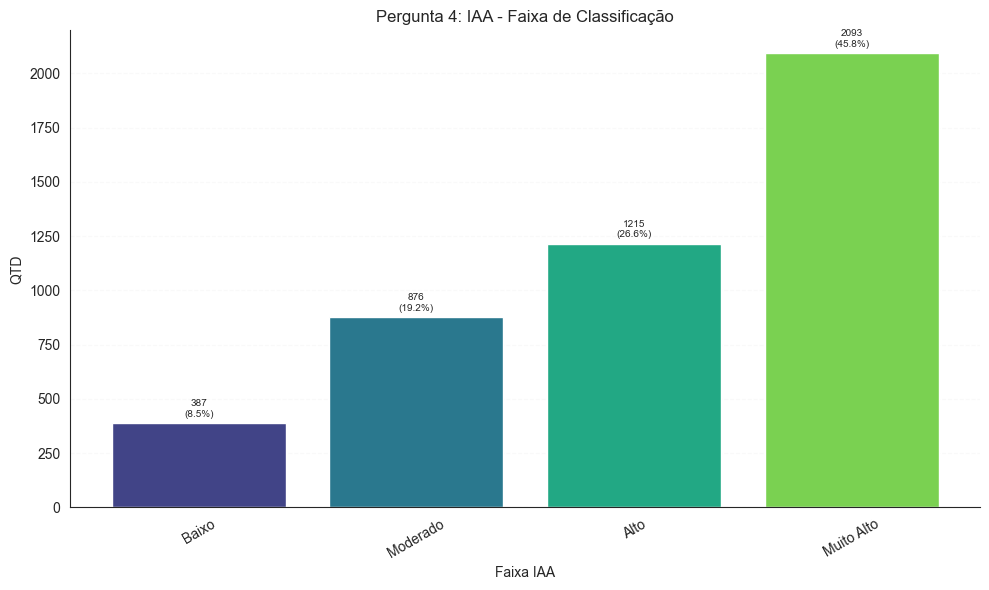

In [29]:
contagem = df['FAIXA_IAA'].value_counts().sort_index()
percentual = contagem / contagem.sum() * 100
sns.set_style("white")
plt.figure(figsize=(10,6))

bars = plt.bar(contagem.index,contagem.values,color=sns.color_palette('viridis', len(contagem)))
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
for i, bar in enumerate(bars):
    altura = bar.get_height()
    pct = percentual.iloc[i]
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + (contagem.max() * 0.01),
        f'{int(altura)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=7.2
    )
plt.title('Pergunta 4: IAA - Faixa de Classificação')
plt.xlabel('Faixa IAA')
plt.ylabel('QTD')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

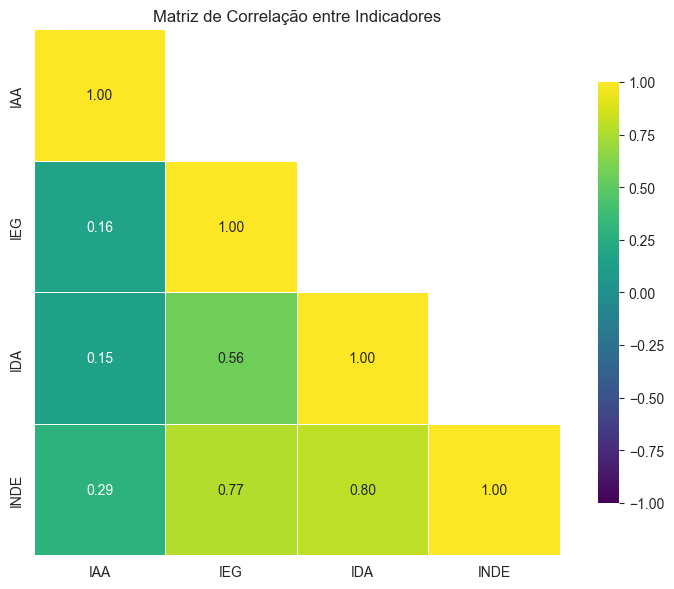

In [30]:
corr = df[['IAA','IEG', 'IDA','INDE']].corr()
diagonal = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8,6))
sns.set_style("white")

ax = sns.heatmap(
    corr,
    mask=diagonal,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Matriz de Correlação entre Indicadores')
plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\945347180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fase_IAA,x='PEDRA',y='IAA',palette=sns.color_palette('viridis', len(fase_IAA)))


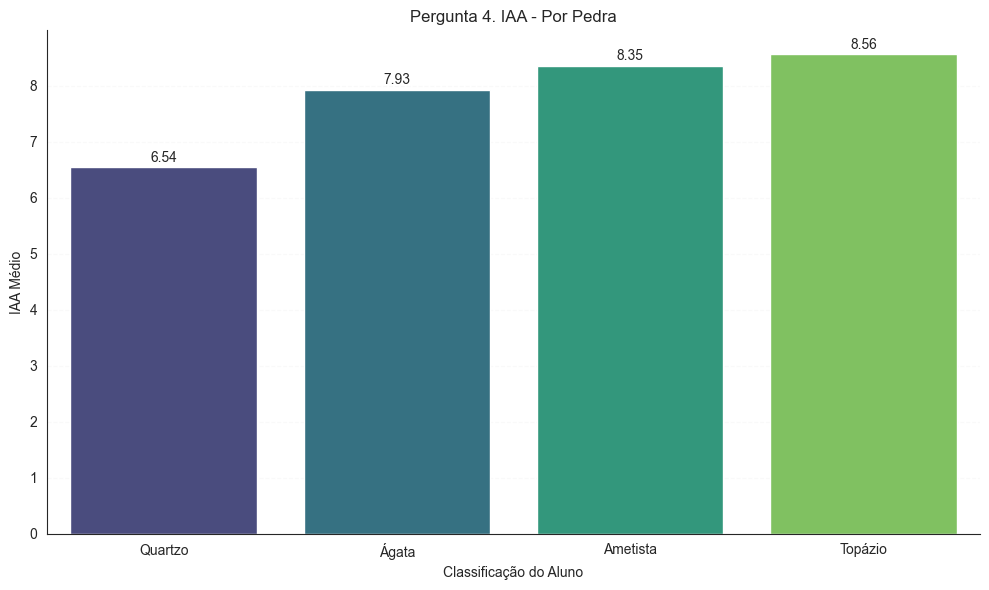

In [31]:
fase_IAA = df.groupby('PEDRA')['IAA'].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=fase_IAA,x='PEDRA',y='IAA',palette=sns.color_palette('viridis', len(fase_IAA)))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + 0.05, 
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title('Pergunta 4. IAA - Por Pedra')
plt.xlabel('Classificação do Aluno')
plt.ylabel('IAA Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------

Pergunta 5. Aspectos psicossociais (IPS)

Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

--------------------------------------------------------------------------------------------------

Pergunta 6. Aspectos psicopedagógicos (IPP)

As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?


In [32]:
df['IPS'] = (df['IPS'].astype(str).str.replace(',', '.'))
df['IPS'] = pd.to_numeric(df['IPS'], errors='coerce')
df['IPP'] = (df['IPP'].astype(str).str.replace(',', '.'))
df['IPP'] = pd.to_numeric(df['IPP'], errors='coerce')

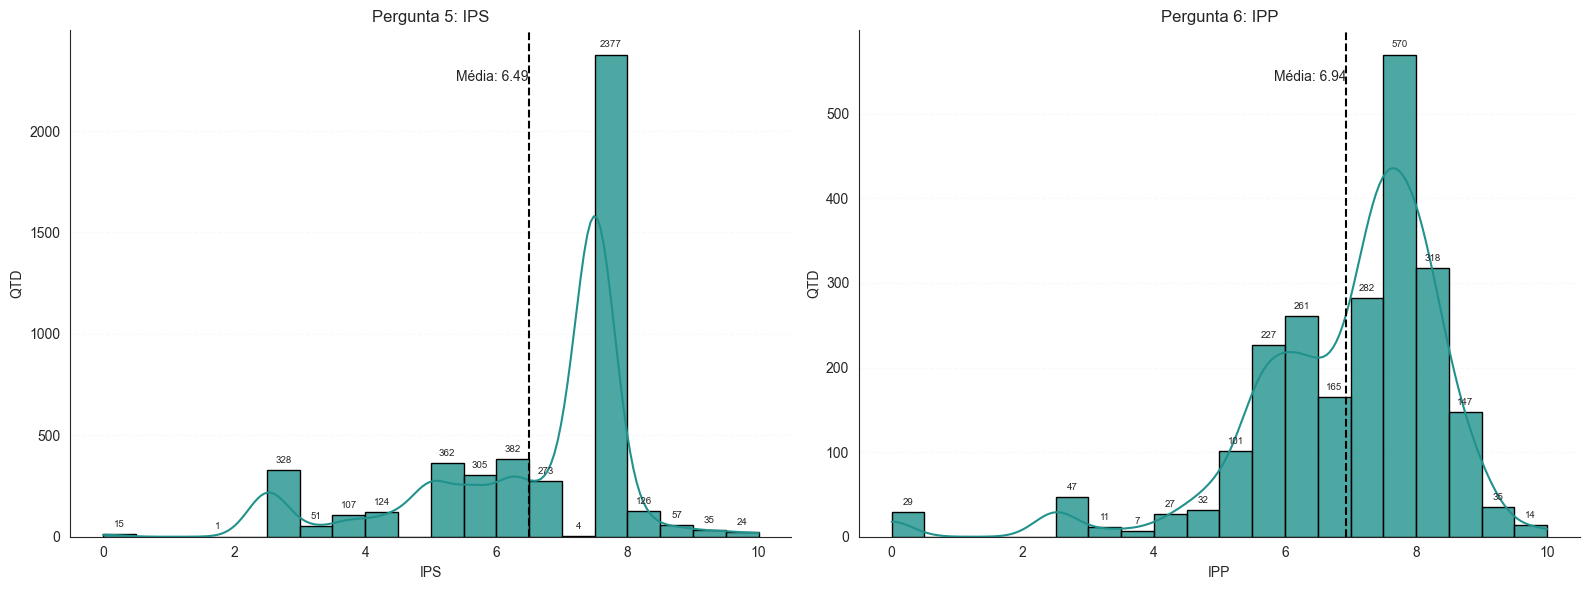

In [33]:
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(16,6))
colunas = ['IPS', 'IPP']
titulos = ['Pergunta 5: IPS', 'Pergunta 6: IPP']
for i, col in enumerate(colunas):
    ax = axes[i]    
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        color=sns.color_palette('viridis', 3)[1],
        edgecolor='black',
        alpha=0.8,
        ax=ax
    )
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    media = df[col].mean()
    ax.axvline(media, linestyle='--', linewidth=1.5, color='black')
    ax.text(media, ax.get_ylim()[1]*0.9, f'Média: {media:.2f}', ha='right')
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.text(
                p.get_x() + p.get_width()/2,
                altura + (ax.get_ylim()[1]*0.01),
                f'{int(altura)}',
                ha='center',
                va='bottom',
                fontsize=7
            )

    ax.set_title(titulos[i])
    ax.set_xlabel(col)
    ax.set_ylabel('QTD')
    ax.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [34]:
def classificar_ips(x):
    if x >= 9:
        return 'Muito Alto'
    elif x >= 7:
        return 'Alto'
    elif x >= 5:
        return 'Moderado'
    else:
        return 'Baixo'

def classificar_ipp(x):
    if x >= 9:
        return 'Muito Alto'
    elif x >= 7:
        return 'Alto'
    elif x >= 5:
        return 'Moderado'
    else:
        return 'Baixo'

df['FAIXA_IPS'] = df['IPS'].apply(classificar_ips)
df['FAIXA_IPP'] = df['IPP'].apply(classificar_ipp)

In [35]:
ordem_IPS = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_IPS'] = pd.Categorical(df['FAIXA_IPS'], categories=ordem_IPS, ordered=True)

In [36]:
ordem_IPP = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_IPP'] = pd.Categorical(df['FAIXA_IPP'], categories=ordem_IPP, ordered=True)


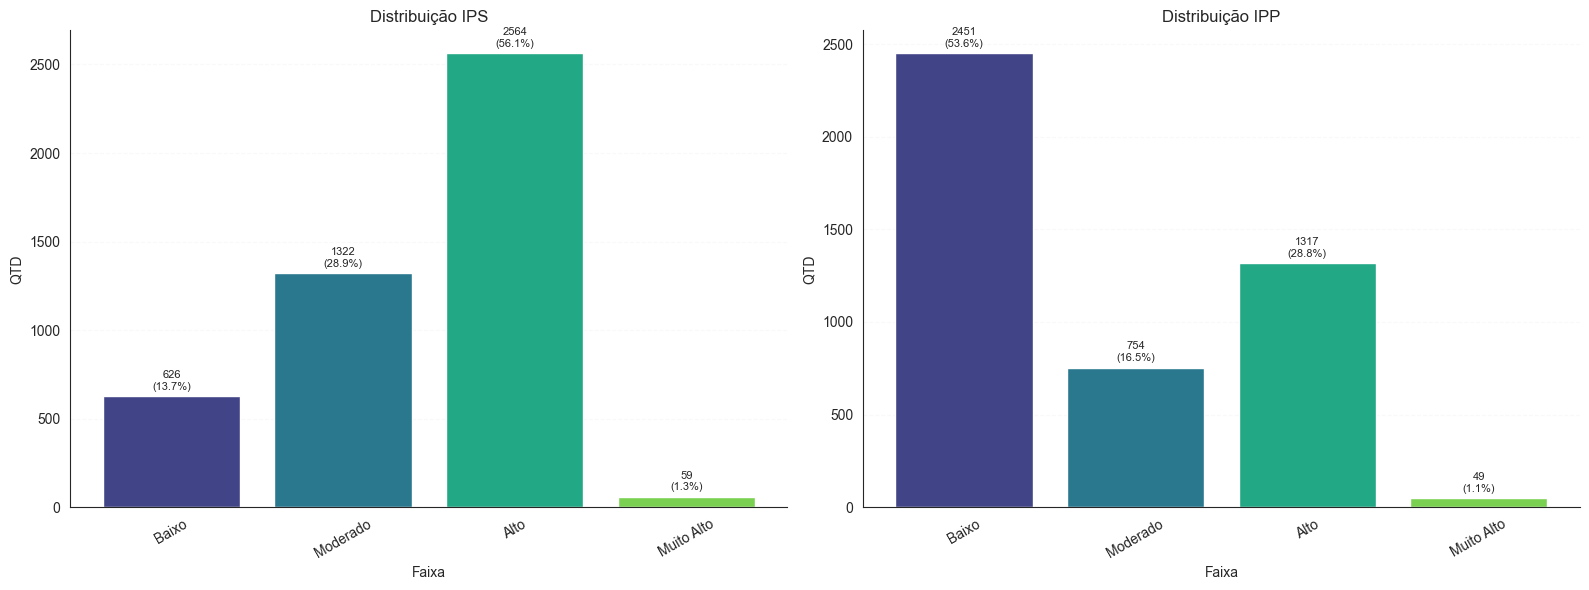

In [37]:
sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(16,6))
colunas = ['FAIXA_IPS', 'FAIXA_IPP']
titulos = ['Distribuição IPS', 'Distribuição IPP']
for i, col in enumerate(colunas):  
    contagem = df[col].value_counts().reindex(ordem_IPS if col == 'FAIXA_IPS' else ordem_IPP)
    percentual = contagem / contagem.sum() * 100
    ax = axes[i]
    bars = ax.bar(
        contagem.index,
        contagem.values,
        color=sns.color_palette('viridis', len(contagem))
    )
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for j, bar in enumerate(bars):
        altura = bar.get_height()
        pct = percentual.iloc[j]
        if altura > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                altura + (contagem.max()*0.01),
                f'{int(altura)}\n({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=8
            )
    ax.set_title(titulos[i])
    ax.set_xlabel('Faixa')
    ax.set_ylabel('QTD')
    ax.grid(axis='y', linestyle='--', alpha=0.1)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

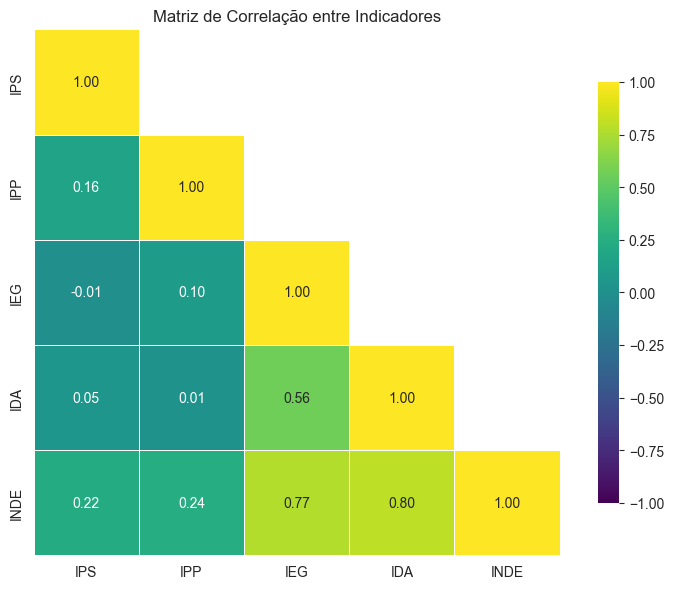

In [38]:
corr = df[['IPS','IPP','IEG','IDA','INDE']].corr()
diagonal = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8,6))
sns.set_style("white")

ax = sns.heatmap(
    corr,
    mask=diagonal,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Matriz de Correlação entre Indicadores')
plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\1021765633.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\1021765633.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


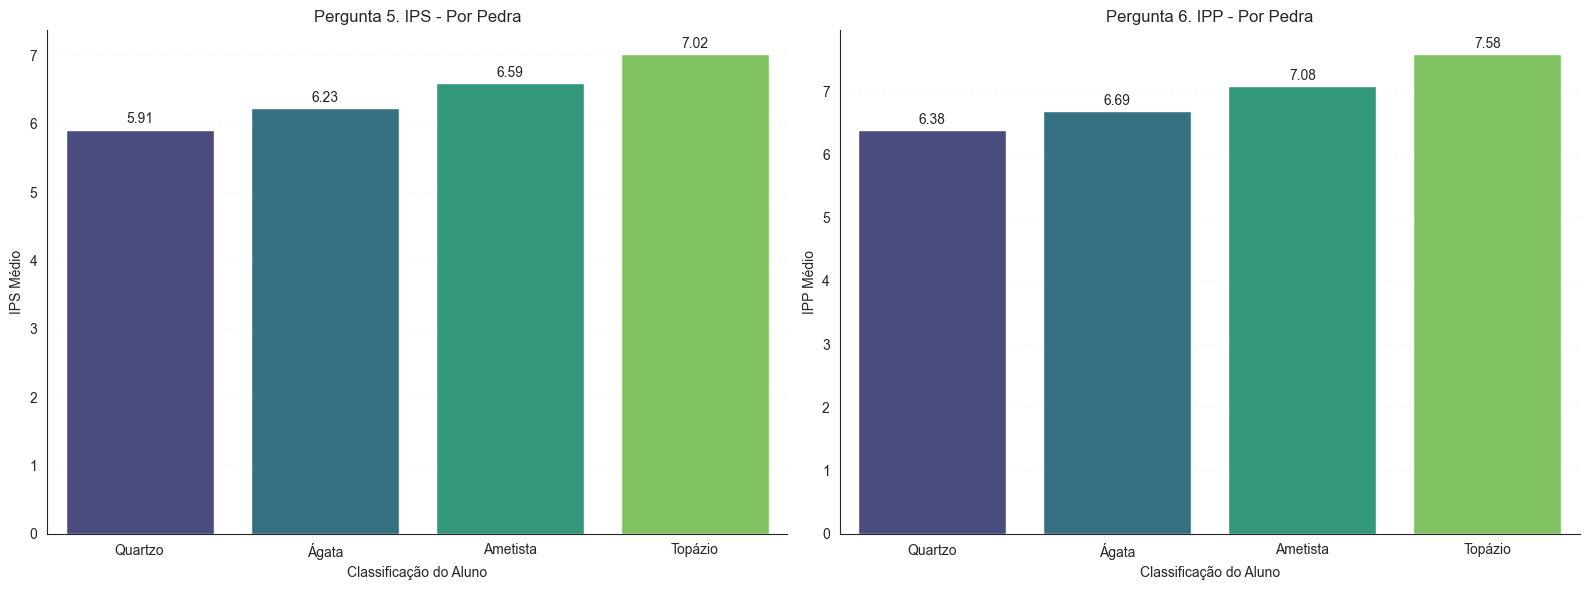

In [39]:
sns.set_style("white")
fase_IPS = df.groupby('PEDRA')['IPS'].mean().reset_index()
fase_IPP = df.groupby('PEDRA')['IPP'].mean().reset_index() 

fig, axes = plt.subplots(1, 2, figsize=(16,6))

bases = [fase_IPS, fase_IPP]
colunas = ['IPS', 'IPP']
titulos = ['Pergunta 5. IPS - Por Pedra', 'Pergunta 6. IPP - Por Pedra']
for i in range(2):
    ax = axes[i]
    base = bases[i]
    col = colunas[i]
    
    sns.barplot(
        data=base,
        x='PEDRA',
        y=col,
        palette=sns.color_palette('viridis', len(base)),
        ax=ax
    )
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.text(
                p.get_x() + p.get_width()/2,
                altura + 0.05,
                f'{altura:.2f}',
                ha='center',
                va='bottom',
                fontsize=10
            )
    ax.set_title(titulos[i])
    ax.set_xlabel('Classificação do Aluno')
    ax.set_ylabel(f'{col} Médio')
    ax.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------

Pergunta 7. Ponto de virada (IPV)

Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [40]:
df['IPV'] = (df['IPV'].astype(str).str.replace(',', '.'))
df['IPV'] = pd.to_numeric(df['IPV'], errors='coerce')

df['IPV'].describe()

count    4571.000000
mean        7.453643
std         1.304586
min         0.000000
25%         6.889500
50%         7.555557
75%         8.250000
max        10.010000
Name: IPV, dtype: float64

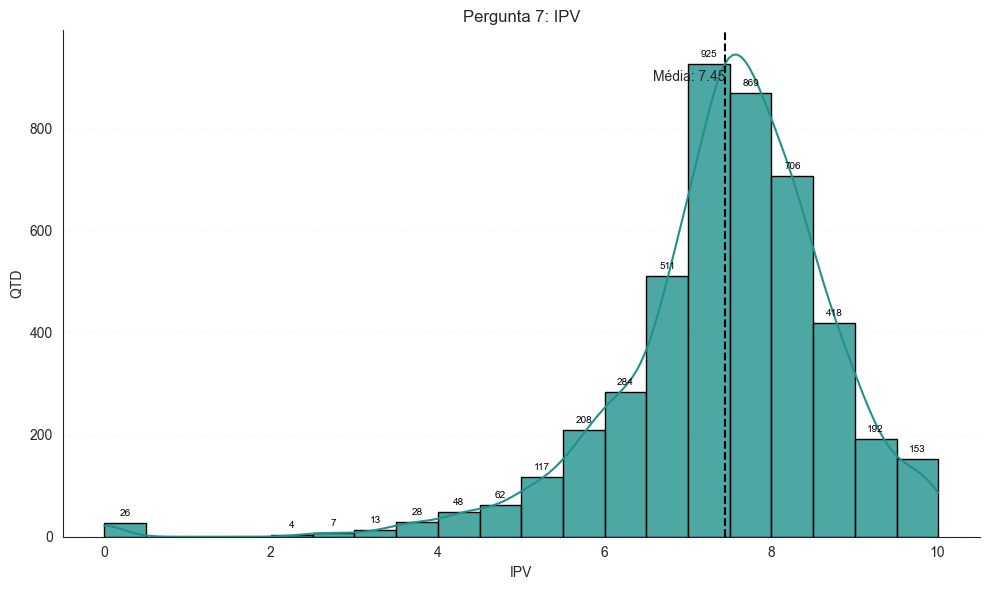

In [41]:
plt.figure(figsize=(10,6))
sns.set_style("white")
ax = sns.histplot(df['IPV'],bins=20,kde=True,color=sns.color_palette('viridis', 3)[1],edgecolor='black',alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

media = df['IPV'].mean()
plt.axvline(media, linestyle='--', linewidth=1.5, color='black')
plt.text(media,ax.get_ylim()[1]*0.9,f'Média: {media:.2f}',ha='right')
for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + (ax.get_ylim()[1]*0.01),
            f'{int(altura)}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=7.2
        )
plt.title('Pergunta 7: IPV')
plt.xlabel('IPV')
plt.ylabel('QTD')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [42]:
def classificar_ipv(x):
    if x >= 8.5:
        return 'Muito Alto'
    elif x >= 7:
        return 'Alto'
    elif x >= 5.5:
        return 'Moderado'
    else:
        return 'Baixo'

df['FAIXA_IPV'] = df['IPV'].apply(classificar_ipv)
df['FAIXA_IPV'].value_counts(normalize=True)

FAIXA_IPV
Alto          0.541895
Moderado      0.213739
Muito Alto    0.179829
Baixo         0.064537
Name: proportion, dtype: float64

In [43]:
ordem_IPV = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_IPV'] = pd.Categorical(df['FAIXA_IPV'], categories=ordem_IPV, ordered=True)

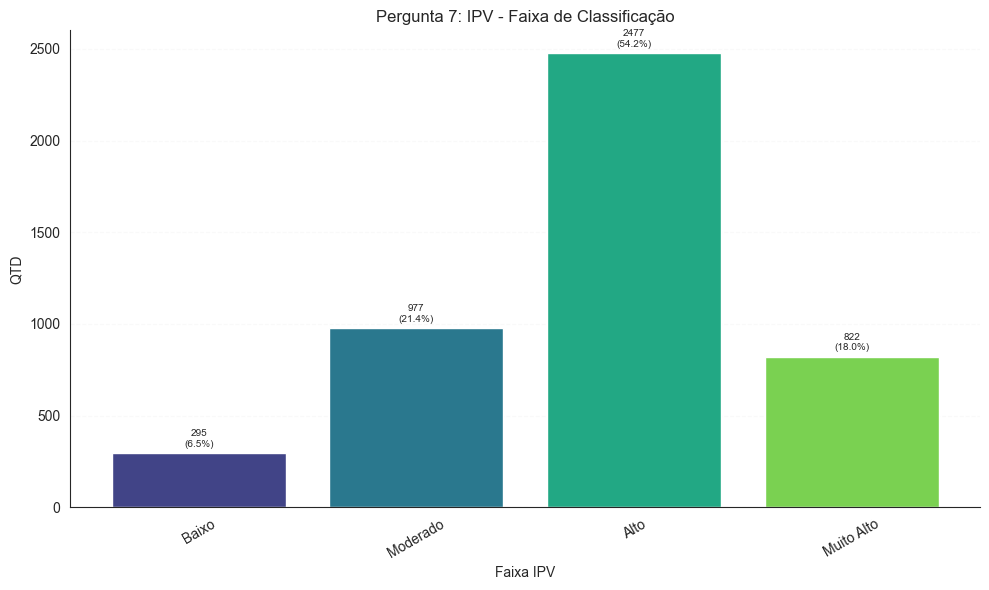

In [44]:
contagem = df['FAIXA_IPV'].value_counts().sort_index()
percentual = contagem / contagem.sum() * 100
sns.set_style("white")
plt.figure(figsize=(10,6))

bars = plt.bar(contagem.index,contagem.values,color=sns.color_palette('viridis', len(contagem)))
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
for i, bar in enumerate(bars):
    altura = bar.get_height()
    pct = percentual.iloc[i]
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + (contagem.max() * 0.01),
        f'{int(altura)}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=7.2
    )
plt.title('Pergunta 7: IPV - Faixa de Classificação')
plt.xlabel('Faixa IPV')
plt.ylabel('QTD')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

C:\Users\vinic\AppData\Local\Temp\ipykernel_12580\2505224387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fase_IPV,x='PEDRA',y='IPV',palette=sns.color_palette('viridis', len(fase_IPV)))


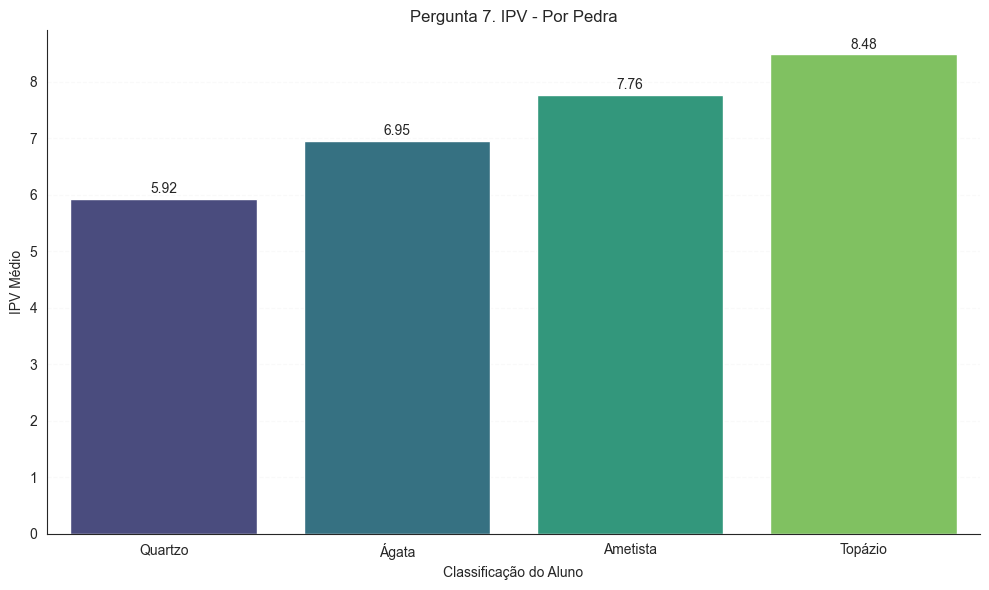

In [45]:
fase_IPV = df.groupby('PEDRA')['IPV'].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=fase_IPV,x='PEDRA',y='IPV',palette=sns.color_palette('viridis', len(fase_IPV)))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + 0.05, 
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title('Pergunta 7. IPV - Por Pedra')
plt.xlabel('Classificação do Aluno')
plt.ylabel('IPV Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

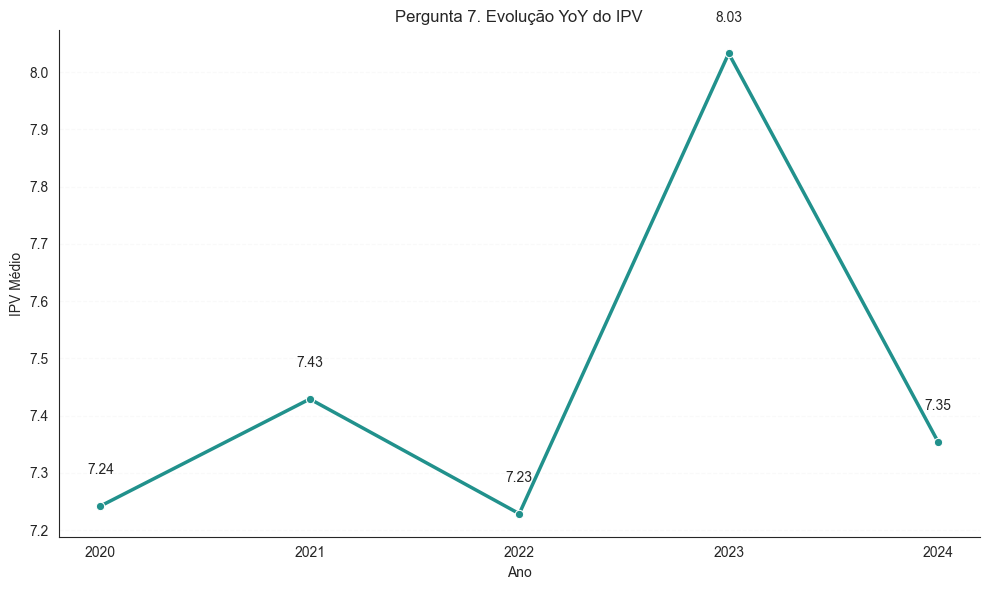

In [46]:
evolucao = df.groupby('ANO')['IPV'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.set_style("white")
sns.lineplot(data=evolucao,x='ANO',y='IPV',marker='o',linewidth=2.5,color=sns.color_palette('viridis', 3)[1])

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

for i in range(len(evolucao)):
    x = evolucao['ANO'].iloc[i]
    y = evolucao['IPV'].iloc[i]
    plt.text(
        x,
        y + 0.05,  
        f'{y:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Pergunta 7. Evolução YoY do IPV')
plt.xlabel('Ano')
plt.ylabel('IPV Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.xticks(evolucao['ANO'].astype(int))

plt.tight_layout()
plt.show()

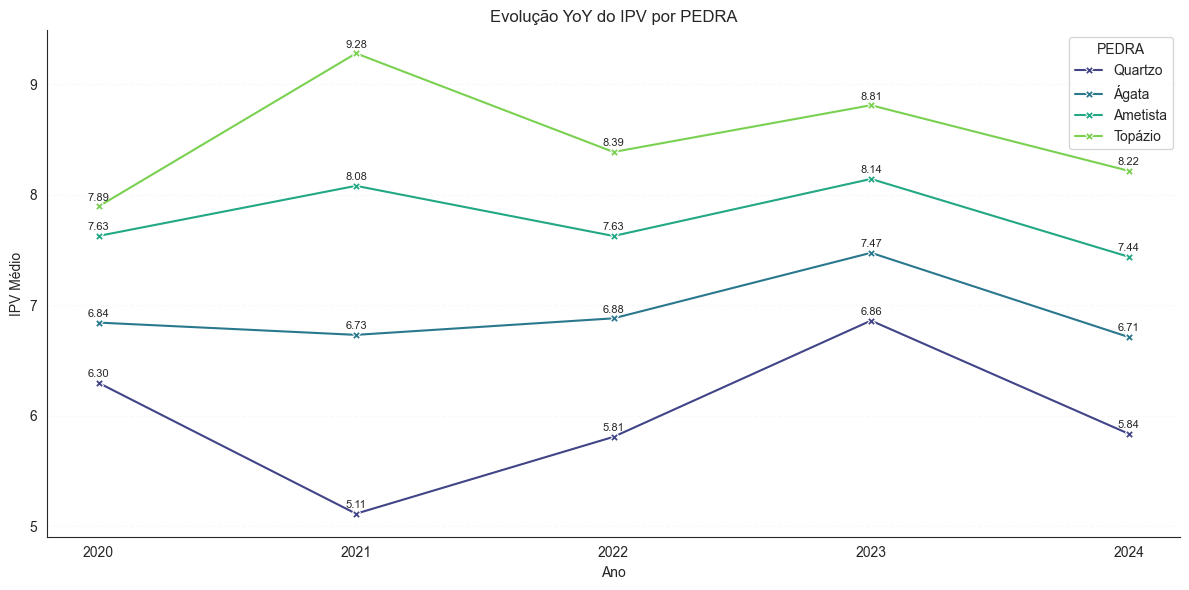

In [47]:
sns.set_style("white")
evolucao = df.groupby(['ANO', 'PEDRA'])['IPV'].mean().reset_index()
plt.figure(figsize=(12,6))
ax = sns.lineplot(data=evolucao,x='ANO',y='IPV',hue='PEDRA',marker='X',linewidth=1.5,palette='viridis')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for _, row in evolucao.iterrows():
    plt.text(
        row['ANO'],
        row['IPV'] + 0.05,
        f"{row['IPV']:.2f}",
        ha='center',
        fontsize=8
    )
plt.title('Evolução YoY do IPV por PEDRA')
plt.xlabel('Ano')
plt.ylabel('IPV Médio')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.xticks(evolucao['ANO'].unique())
plt.legend(title='PEDRA')

plt.tight_layout()
plt.show()

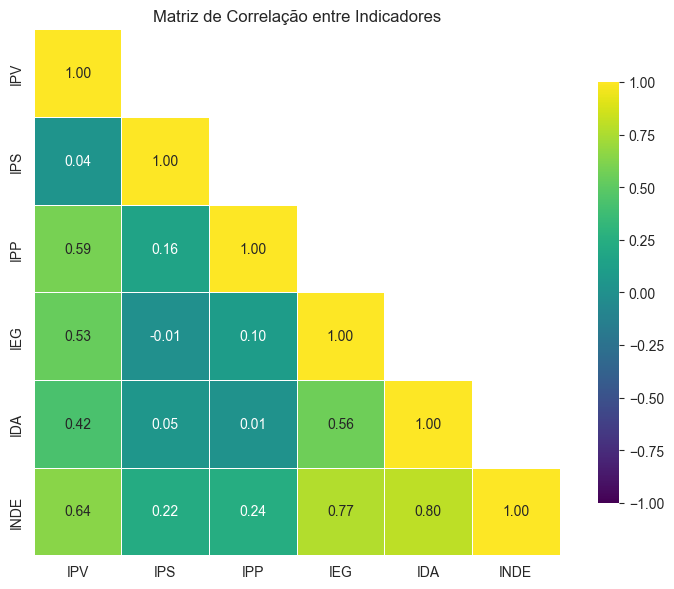

In [48]:
corr = df[['IPV','IPS','IPP','IEG','IDA','INDE']].corr()
diagonal = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8,6))
sns.set_style("white")

ax = sns.heatmap(
    corr,
    mask=diagonal,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Matriz de Correlação entre Indicadores')
plt.tight_layout()
plt.show()

-------------------------------------------

In [49]:
df.groupby('PONTO_VIRADA')['IPV'].mean().reset_index()

,PONTO_VIRADA,IPV
0,0,7.316270
1,1,9.136361


In [50]:
df.groupby(['PONTO_VIRADA','PEDRA'])[['IEG','IDA','IPP','IPS','IAA']].mean().round(2)

IEG   IDA   IPP   IPS   IAA
PONTO_VIRADA PEDRA                                 
0            Quartzo   4.91  2.90  6.38  5.91  6.54
             Ágata     7.20  5.19  6.68  6.23  7.94
             Ametista  8.58  6.91  6.98  6.56  8.33
             Topázio   9.39  8.22  7.04  6.87  8.38
1            Ágata     7.98  5.20  8.18  6.25  3.06
             Ametista  8.55  6.99  7.74  6.98  8.60
             Topázio   9.45  8.13  8.05  7.56  9.24

In [51]:
df.groupby('FAIXA_IPV')[['IEG','IDA','IPP','IPS','IAA']].mean().round(2)

,IEG,IDA,IPP,IPS,IAA
FAIXA_IPV,,,,,
Baixo,5.05,3.98,5.20,6.13,7.44
Moderado,6.94,4.99,6.59,6.49,7.68
Alto,8.25,6.47,7.05,6.54,8.21
Muito Alto,9.04,7.62,8.00,6.50,8.21


In [52]:
df.groupby('PEDRA')[['IPV','IEG','IDA','IPP','IPS']].mean().round(2)

,IPV,IEG,IDA,IPP,IPS
PEDRA,,,,,
Quartzo,5.92,4.91,2.90,6.38,5.91
Ágata,6.95,7.20,5.20,6.69,6.23
Ametista,7.76,8.58,6.91,7.08,6.59
Topázio,8.48,9.40,8.20,7.58,7.02


# -------------------------------------------------------------------------------------------

Pergunta 8.  Multidimensionalidade dos indicadores

Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

In [53]:
df['INDE'] = (df['INDE'].astype(str).str.replace(',', '.'))
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')
df['INDE'].describe()

count    4571.000000
mean        7.194965
std         1.099514
min         2.468000
25%         6.591230
50%         7.356358
75%         7.982762
max         9.712504
Name: INDE, dtype: float64

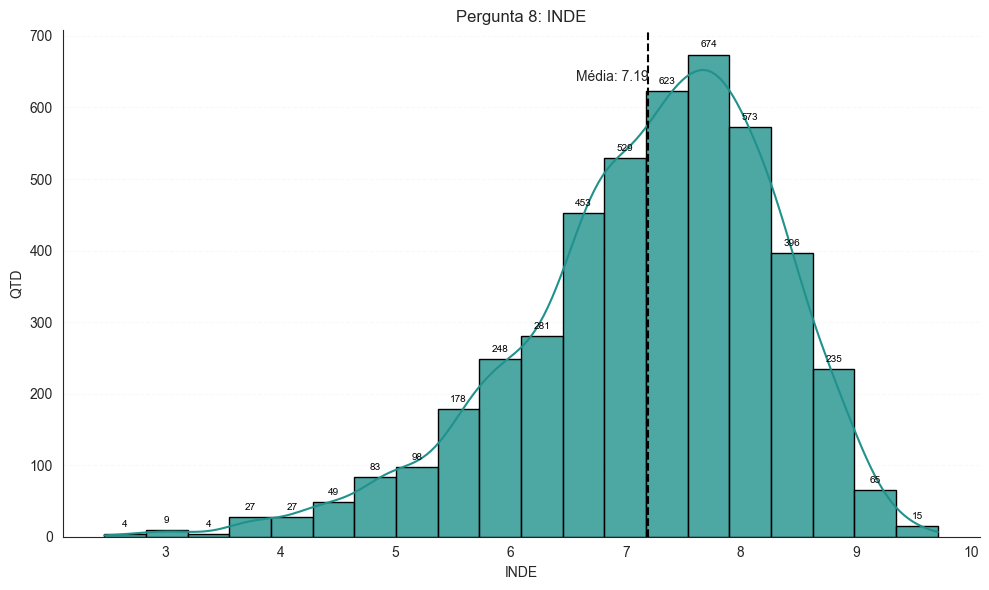

In [54]:
plt.figure(figsize=(10,6))
sns.set_style("white")
ax = sns.histplot(df['INDE'],bins=20,kde=True,color=sns.color_palette('viridis', 3)[1],edgecolor='black',alpha=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

media = df['INDE'].mean()
plt.axvline(media, linestyle='--', linewidth=1.5, color='black')
plt.text(media,ax.get_ylim()[1]*0.9,f'Média: {media:.2f}',ha='right')
for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            altura + (ax.get_ylim()[1]*0.01),
            f'{int(altura)}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=7.2
        )
plt.title('Pergunta 8: INDE')
plt.xlabel('INDE')
plt.ylabel('QTD')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [55]:
def classificar_inde(x):
    if x >= 8.5:
        return 'Muito Alto'
    elif x >= 7:
        return 'Alto'
    elif x >= 5.5:
        return 'Moderado'
    else:
        return 'Baixo'

df['FAIXA_INDE'] = df['INDE'].apply(classificar_inde)

In [56]:
ordem_INDE = ['Baixo', 'Moderado', 'Alto', 'Muito Alto']
df['FAIXA_INDE'] = pd.Categorical(df['FAIXA_INDE'], categories=ordem_INDE, ordered=True)

In [57]:
drivers = df.groupby('FAIXA_INDE')[['IEG','IDA','IPV','IPP','IPS','INDE']].mean().round(2)

drivers

,IEG,IDA,IPV,IPP,IPS,INDE
FAIXA_INDE,,,,,,
Baixo,3.94,2.27,5.56,6.41,5.94,4.73
Moderado,6.99,4.87,6.85,6.67,6.17,6.40
Alto,8.71,7.11,7.87,7.08,6.62,7.73
Muito Alto,9.59,8.61,8.59,7.73,7.33,8.81


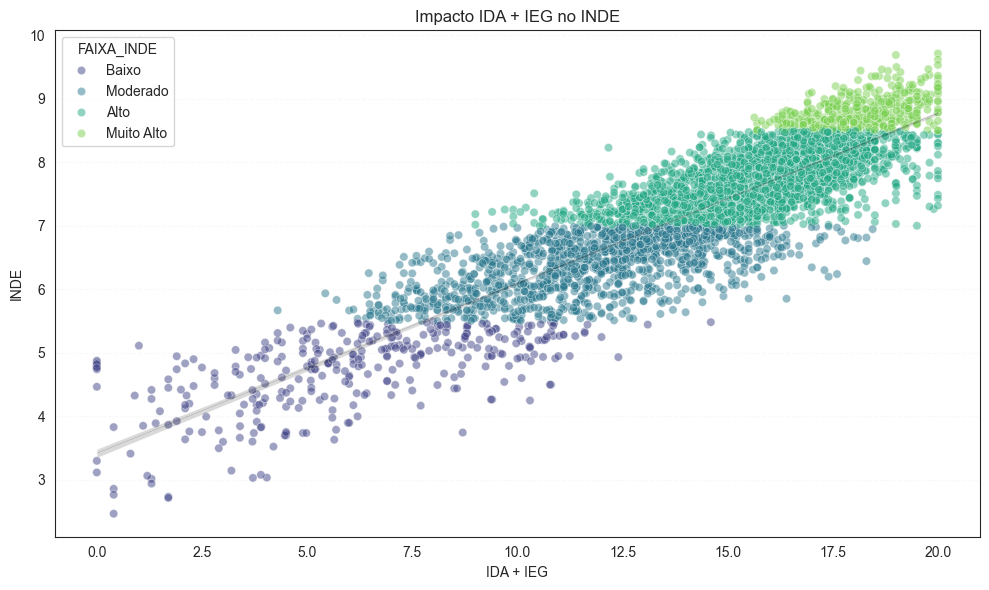

In [58]:
df['IDA_IEG'] = df['IDA'] + df['IEG']
sns.set_style("white")
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='IDA_IEG',
    y='INDE',
    hue='FAIXA_INDE',
    palette='viridis',
    alpha=0.5
)
sns.regplot(
    data=df,
    x='IDA_IEG',
    y='INDE',
    scatter=False,
    color='black',
    line_kws={'linestyle':'--', 'linewidth':0.1}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Impacto IDA + IEG no INDE')
plt.xlabel('IDA + IEG')
plt.ylabel('INDE')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

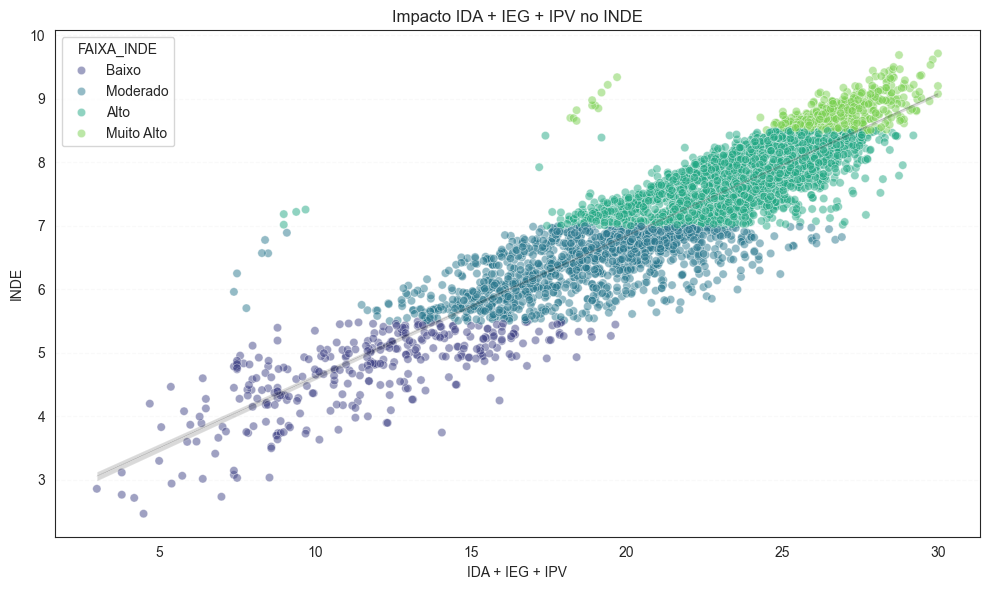

In [62]:
df['IDA_IEG_IPV'] = df['IDA'] + df['IEG'] + df['IPV']
sns.set_style("white")
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='IDA_IEG_IPV',
    y='INDE',
    hue='FAIXA_INDE',
    palette='viridis',
    alpha=0.5
)
sns.regplot(
    data=df,
    x='IDA_IEG_IPV',
    y='INDE',
    scatter=False,
    color='black',
    line_kws={'linestyle':'--', 'linewidth':0.1}
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Impacto IDA + IEG + IPV no INDE')
plt.xlabel('IDA + IEG + IPV')
plt.ylabel('INDE')
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [63]:
from sklearn.linear_model import LinearRegression
X = df[['IDA', 'IEG']]
y = df['INDE']
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)
print(f'r²: {r2:.4f}')
print(f'{r2*100:.2f}% do INDE é explicado por IDA + IEG')


r²: 0.7920
79.20% do INDE é explicado por IDA + IEG


In [64]:
from sklearn.linear_model import LinearRegression
X = df[['IDA', 'IEG', 'IPV','IAN']]
y = df['INDE']
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)
print(f'r²: {r2:.4f}')
print(f'{r2*100:.2f}% do INDE é explicado por IDA + IEG + IPV + IAN')


r²: 0.8970
89.70% do INDE é explicado por IDA + IEG + IPV + IAN
